In [3]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', as_frame=False)

# Separate the data and target
X, y = mnist["data"], mnist["target"]

In [ ]:
X.shape # (columns, rows)

In [ ]:
y # Target labels

In [ ]:
%pip install matplotlib

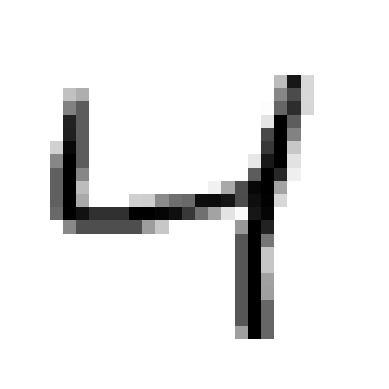

In [4]:
import matplotlib.pyplot as plt

def plot_img(image_data):
    img = image_data.reshape(28,28)
    plt.imshow(img, cmap="binary")
    plt.axis("off")

some_digit = X[2]
plot_img(some_digit)
plt.show()

In [ ]:
y[1]

In [5]:
from sklearn.model_selection import train_test_split
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# train a multiclass classifier using RF
from sklearn.ensemble import RandomForestClassifier
print("Train Random Forest Classifier...")
model = RandomForestClassifier(n_estimators=100, n_jobs = -1, random_state=42)
model.fit(X_train, y_train)

Train Random Forest Classifier...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Train using Stochastic Gradient Descent (SGD) Classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)

In [7]:
# Predicting using the trained model
model.predict([some_digit])

array(['4'], dtype=object)

In [8]:
# Cross Validation to measure accuracy of the model
from sklearn.model_selection import cross_val_score

# Creating 5 folds/ small sets to perform cross validation and measuring accuracy aka training the model 3 times and evaluating it on a different fold each time
cross_val_score(model, X_train, y_train, cv =3 , scoring="accuracy")

array([0.96485777, 0.96833985, 0.96565949])

In [ ]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_2)
print(any(dummy_clf.predict(X_train)))

In [ ]:
cross_val_score(dummy_clf, X_train, y_train_2, cv = 3, scoring="accuracy")

In [ ]:
# Stratified K-fold Cross Validation

from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold
skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_idx, test_idx in skfolds.split(X_train, y_train_2):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_idx]
    y_train_folds = y_train_2[train_idx]
    X_test_fold = X_train[test_idx]
    y_test_fold = y_train_2[test_idx]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_predict = clone_clf.predict(X_test_fold)
    n_correct = sum(y_predict == y_test_fold)

    print(n_correct / len(y_predict))


In [9]:
from sklearn.model_selection import cross_val_predict

# performing cross validation on 3 sets and getting the predicted values for each test fold
y_train_pred = cross_val_predict(model, X_train, y_train, cv=3)

from sklearn.metrics import confusion_matrix
# establising confusion matrix by comparing predicted values with actual values
cm = confusion_matrix(y_train, y_train_pred)
cm


array([[5489,    1,    5,    0,    3,    7,   21,    1,   31,    2],
       [   1, 6177,   36,   15,   11,    4,    8,   10,   10,    5],
       [  26,    9, 5416,   28,   25,    3,   20,   40,   33,   10],
       [   7,    9,   75, 5437,    2,   53,    6,   44,   52,   23],
       [   9,    7,    6,    0, 5360,    0,   29,   10,   14,   94],
       [  23,    4,    9,   61,   10, 4824,   48,    8,   32,   21],
       [  26,   12,    5,    0,    8,   26, 5383,    0,   20,    0],
       [   5,   19,   57,    5,   34,    1,    0, 5586,   10,   73],
       [  20,   28,   26,   40,   25,   39,   27,    6, 5195,   62],
       [  24,   10,   16,   79,   67,   17,    3,   42,   35, 5245]])

In [10]:
# comparing actual values with itself to determine ideal cm

y_predict_perf = y_train
confusion_matrix(y_train, y_predict_perf)

array([[5560,    0,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0, 6277,    0,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0, 5610,    0,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0, 5708,    0,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0, 5529,    0,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0, 5040,    0,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0, 5480,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0, 5790,    0,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0, 5468,    0],
       [   0,    0,    0,    0,    0,    0,    0,    0,    0, 5538]])

In [ ]:
from sklearn.metrics import precision_score, recall_score

# establising precision and recall scores from the cm (actual vs predicted)
precision_score(y_train, y_train_pred)
recall_score(y_train, y_train_pred)

In [ ]:
from sklearn.metrics import f1_score

# f1 score is the harmonic mean of precision and recall aka when recall and precision are equally important
f1_score(y_train_2, y_train_pred)

In [ ]:
# decision function gives the confidence score for each instance being classified as positive (1) or negative (0)
y_scores = sgd_clf.decision_function([some_digit])
y_scores

In [ ]:
# Threshold is the value above which the model will classify an instance as positive (1) and below which it will classify it as negative (0)

threshold = 1800
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

In [ ]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_2, cv=3, method="decision_function") # confidence scores for all instances in the training set

In [ ]:
from sklearn.metrics import precision_recall_curve

# calculating precision and recall for all possible thresholds by comparing the true labels with the predicted scores
precisions, recalls, thresholds = precision_recall_curve(y_train_2, y_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="Threshold")
plt.grid(True)
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.legend()

In [ ]:
indx_for_90_precision = (precisions >= 0.90).argmax() #index of the first threshold for which precision is greater than or equal to 90%
threshold_90_precision = thresholds[indx_for_90_precision]
threshold_90_precision

In [ ]:
y_train_pred_90 = (y_scores >= threshold_90_precision) # making predictions based on the threshold for 90% precision
precision_score(y_train_2, y_train_pred_90)
recall_score(y_train_2, y_train_pred_90)

In [ ]:
# ROC Curve - Receiver Operating Characteristic Curve - plots the true positive rate (recall) against the false positive rate at various threshold settings
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_2, y_scores)

In [ ]:
# point for 90% precision
idx_for_threshold_90 = (thresholds >= threshold_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_90], fpr[idx_for_threshold_90]
tpr_90, fpr_90

In [ ]:
plt.plot(fpr, tpr, linewidth=2, label="ROC Curve")
plt.plot([0,1], [0,1], "k:", label="Random Classifier")
plt.plot(fpr_90, tpr_90, "ro", label="Threshold 90% Precision")
plt.grid(True)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_2, y_scores)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier does not have a decision function but it has a predict_proba method that gives the probability of each instance being classified as positive (1) or negative (0)
forest_clf = RandomForestClassifier(random_state=42)

y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_2, cv=3, method="predict_proba")

In [ ]:
y_probas_forest[:2]

In [ ]:
y_scores_forest = y_probas_forest[:, 1] # score = proba of positive class
precision_forest, recall_forest, thresholds_forest = precision_recall_curve(y_train_2, y_scores_forest)

In [ ]:
plt.plot(recall_forest, precision_forest, "b-", linewidth=2,
label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

In [ ]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # positive proba ≥ 50%
f1_score(y_train_2, y_train_pred_forest)

In [ ]:
roc_auc_score(y_train_2, y_scores_forest)

In [ ]:
recall_score(y_train_2, y_train_pred_forest)

In [ ]:
precision_score(y_train_2, y_train_pred_forest)

In [ ]:
# Train on SVM for multiclass classification
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
# training on only 2000 data samples
svm_clf.fit(X_train[:2000], y_train[:2000])


In [ ]:
svm_clf.predict([some_digit]) # some digit = 4

In [ ]:
some_digits_score = svm_clf.decision_function([some_digit])
some_digits_score.round(2)
# highest score is for class4 i.e. model is most confident that the given digit is 4

In [ ]:
some_digits_score.argmax()

In [ ]:
svm_clf.classes_
# classes/labels/ digits model predicts

In [ ]:
# Train a one vs rest model using SVM
from sklearn.multiclass import OneVsRestClassifier

onevrest = OneVsRestClassifier(SVC(random_state=42))
onevrest.fit(X_train[:2000], y_train[:2000])

In [ ]:
# Make predictions 
onevrest.predict([some_digit])

# Check number of classifiers it trained
onevrest.classes_

In [ ]:
# Train SGD classifiers
from sklearn.linear_model import SGDClassifier

sgd_clf_ovr = OneVsRestClassifier(SGDClassifier(random_state=42))
sgd_clf_ovr.fit(X_train[:2000], y_train[:2000])

In [ ]:
# some other digit
some_other_digit = X[0]
plt.imshow(some_other_digit.reshape(28,28), cmap="binary")

In [ ]:
# Predict using SGD
sgd_clf_ovr.predict([some_other_digit])
# if wrongly classifies as another class, check confidence scores

In [ ]:
# Checking accuracy of the model
cross_val_score(sgd_clf_ovr, X_train, y_train, cv=3, scoring="accuracy")

In [ ]:
# Scaling inputs to improve accuracy of the model
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.astype("float64"))
cross_val_score(sgd_clf_ovr, X_train_scaled, y_train, cv=3, scoring="accuracy")

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Creating confusion matrix for multiclass classification
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=3) # gives prediction values on validation sets
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred) # cm between actual and predicted values
plt.show()


In [ ]:
# Normalizing (dividing each value by total no. of images in true class)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")

In [ ]:
# cm of misclassified samples is done by shifting sample weight from correct to incorrect classification

sample_weight = (y_train != y_train_pred)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight,normalize="true", values_format=".0%")
plt.show()

MULTILABEL CLASSIFICATION

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# 2 labels = Large number, Odd number
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)

y_multilabel = np.c_[y_train_large, y_train_odd]

In [ ]:
# Train KNN classifier
knn_Clf = KNeighborsClassifier()
knn_Clf.fit(X_train, y_multilabel)

In [ ]:
knn_Clf.predict([some_digit]) # 2

In [ ]:
y_train_knn_predict = cross_val_predict(knn_Clf, X_train, y_multilabel, cv=3)

In [ ]:
f1_score(y_multilabel, y_train_knn_predict, average="macro")

In [ ]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])


In [ ]:
chain_clf.predict([some_other_digit]) # 0- False, 1- True

MULTIOUTPUT CLASSIFICATION

In [ ]:
# creating images containing noise, to train model to remove noise

np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_noisy = X_train + noise # the input data with noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_noisy = X_test + noise

In [ ]:
y_train_noisy = X_train # original data as the output data
y_test_noisy = X_test

In [ ]:
peek = X_test_noisy[0]
plt.imshow(peek.reshape(28,28), cmap="binary")

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_noisy, y_train_noisy)

In [ ]:
clean_digit = knn_clf.predict([X_test_noisy[0]])
plot_img(clean_digit)
plt.show()